## Evaluating modelled CA1 activity on a linear track

Basic version:
* Linear track (approx 5 runs)
* CA3: 8 preset place fields
* CA1: 
  * Receives reward signal at the dendrites
  * Local learning
  * (1) 1 cell => (2) population with lateral inhibition

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from pathlib import Path
import sys
import warnings

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import tqdm

import ratinabox 
from ratinabox import utils as rat_utils
from ratinabox import Environment
from ratinabox import PlaceCells

add_paths = [str(Path(".."))]
for add_path in add_paths:
    if add_path not in sys.path:
        sys.path.append(add_path)

from predhpc import agent, neurons, util

In [2]:
warnings.filterwarnings("ignore", message="Warning: You have solid 1D boundary", category=UserWarning)

In [3]:
import importlib
importlib.reload(agent)
importlib.reload(neurons)
importlib.reload(util)

<module 'predhpc.util' from '/home/cgillon/Documents/predhpc/scripts/../predhpc/util.py'>

In [4]:
ratinabox.stylize_plots()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

## Define some functions

In [5]:
FIGSIZE = (5, 3)
FIGSIZE_SQUAT = (5, 1.5)
def plot_environment(Ag):
    fig, ax = Ag.Environment.plot_environment()
    ax.plot(Ag.start_pos, 0, marker="o", color="blue", zorder=5)
    ax.plot(Ag.reset_pos, 0, marker="x", color="red", zorder=5)
    ax.set_title("Environment")
    
def plot_all_place_weights(CA1_weights, CA3_PCs, cmap="crest", reward_lr_fact=None):
    CA1_weights = np.asarray(CA1_weights)
    num_samples, num_cells, num_inputs = CA1_weights.shape
    
    cmap_vals = np.linspace(0, 1, num_samples)
    colors = sns.color_palette(cmap, as_cmap=True)(cmap_vals)
    alpha = 0.8 ** (len(colors) / 6)
    
    fig, ax = plt.subplots(figsize=(5, num_cells * 2))
    spacing = (CA1_weights.max() - CA1_weights.min()) * 1.1
    for n in range(num_cells):
        for i, color in enumerate(colors):
            label = None
            if n == 0: 
                if i == 0:
                    label = "first"
                elif i == len(colors) - 1:
                    label = "last"
            offset = spacing * n
            ax.plot(
                CA3_PCs.place_cell_centres[:, 0], 
                CA1_weights[i, n] + offset, color=color, alpha=alpha, label=label
            )
            ax.axhline(offset, color="k", alpha=0.1, lw=0.5, ls="dashed", zorder=-12)
    
    ax.legend()
    ax.set_xlabel("Input place cell center / m")
    ax.set_ylabel("Weights")
    ax.spines[['top', 'right']].set_visible(False) 
    title = "Input weights across learning"
    if reward_lr_fact is not None:
        title = f"{title}\nlr fact={reward_lr_fact} (bottom to top)"
    ax.set_title(title)
    
class handle_1D_place_cell_centres(): # handle an error in place center plotting for 1D place cells
    def __init__(self, PCs):
        self.PCs = PCs
        self.PCs.place_cell_centres =  np.pad(self.PCs.place_cell_centres, ((0, 0), (0, 1)))
    def __enter__(self):
        return
    def __exit__(self, type, value, traceback):
        self.PCs.place_cell_centres =  self.PCs.place_cell_centres[:, :1]

In [6]:
def learn(env_params, agent_params, CA3_PC_params, CA1_params, num_rwd=200, max_steps=5000):
    
    names = [
        "# CA3 PCs", "# CA1s", "CA1 init at 0", "CA1 init scale", 
        "# rewards", "Max # steps"
    ]
    values = [
        CA3_PC_params["n"], CA1_params["n"], CA1_params["init_weights_zero"], 
        CA1_params["w_init_scale"], num_rwd, max_steps
    ]
    print_vals = [f"{name:16}: {value}" for name, value in zip(names, values)]
    print("{}\n".format('\n'.join(print_vals)))
    
    Env = Environment(params=env_params)
    Ag = agent.ResetAgent(Env, params=agent_params)
    CA3_PCs = PlaceCells(Ag, params=CA3_PC_params)

    CA1_params["input_layers"] = [CA3_PCs]
    CA1 = neurons.BTSPLayer(Ag, params=CA1_params)
    CA1.set_freeze()
    CA1.set_btsp_learn()
    
    plot_environment(Ag)

    # plot CA3 properties
    with handle_1D_place_cell_centres(CA3_PCs):
        fig, ax = CA3_PCs.plot_place_cell_locations()
    ax.set_title("CA3 place cell locations")
    fig, ax = plt.subplots(figsize=FIGSIZE_SQUAT)
    CA3_PCs.plot_rate_map(chosen_neurons="all", fig=fig, ax=ax)
    ax.set_title("CA3 rate map")
    
    # run learning
    CA1_weights = [CA1.inputs[CA3_PCs.name]["w"].copy()]
    for i in tqdm(range(max_steps)):
        Ag.update()
        CA3_PCs.update()

        btsp_targs = []
        if Ag.check_reset_pos():
            btsp_targs = [0]
        CA1.update(btsp_targs=btsp_targs)
        if not i % 100:
            CA1_weights.append(CA1.inputs[CA3_PCs.name]["w"].copy())

        if len(Ag.reached_reset_pos) >= num_rwd:
            break
    
    if len(Ag.reached_reset_pos) < num_rwd:
        print(f"Only reached the reward {len(Ag.reached_reset_pos)} times (target: {num_rwd}).")
    
    Ag.log_trajectory_stats_to_date()
    Ag.log_trajectory_stats_to_date(time=False)
    
    plot_all_place_weights(CA1_weights, CA3_PCs)

    for start in ["first", "mid", "final"]:
        fig, ax = plt.subplots(figsize=FIGSIZE_SQUAT)
        t = i * Ag.dt
        num_sec = t * 0.05
        if start == "first":
            t_start = 0
        elif start == "mid":
            t_start = min((t - num_sec) / 2, t - 100 * Ag.dt)
        else:
            t_start = min(t - num_sec, t - 100 * Ag.dt)
        t_start = max(0, t_start)
        t_end = min(i + 1, t_start + num_sec)
        CA1.plot_rate_map(chosen_neurons="all", fig=fig, ax=ax, t_start=t_start, t_end=t_end, shift=-10, overlap=1) #, method="history")
        ax.set_title(f"CA1 rate map ({start} 5% of duration, min. 100 steps)")

    fig, ax = plt.subplots(figsize=FIGSIZE)
    Ag.plot_trajectory_resets(framerate=1/Ag.dt, fig=fig, ax=ax)
    ax.set_title("Trajectories")

    fig, ax = plt.subplots(figsize=FIGSIZE_SQUAT)
    CA1.plot_rate_timeseries(chosen_neurons="all", spikes=True, fig=fig, ax=ax, shift=-10, overlap=1)
    ax.set_title("CA1 rate timeseries")
    
    fig, ax = plt.subplots(figsize=FIGSIZE_SQUAT)
    CA3_PCs.plot_rate_timeseries(chosen_neurons="all", spikes=True, fig=fig, ax=ax)
    ax.set_title("CA3 rate timeseries")
    
    return Env, Ag, CA1, CA3_PCs

## Set hyperparameters

In [7]:
env_params = {
    "dimensionality": "1D",
    "scale": 1,
}

dt = 0.02
agent_params = {
    "reset_tolerance_prop": 0.8,
    "dt": dt,
    "speed_mean": 1, # sets directionality
    "speed_std": 0.5, 
    "start_pos": 0 + dt,
    "reset_pos": env_params["scale"] - dt,
    "fixed_direction": True,
}

CA3_PC_params = {
    "name": "CA3_PCs",
    "n": 8,
    "description": "gaussian_threshold",
    "min_fr": 0,
    "max_fr": 10,
    "color": "C5",
    "widths": agent_params["dt"] * 5,
}

CA1_params = {
    "name": "CA1_BTSP",
    "color": "C2",
    "biases": None,
    "lr": 1e-4,
    "btsp_tau": dt * 8,
    "btsp_fr": 10,
}

In [8]:
import importlib
importlib.reload(util)
importlib.reload(neurons)

<module 'predhpc.neurons' from '/home/cgillon/Documents/predhpc/scripts/../predhpc/neurons.py'>

## Only 1 CA1 neuron

In [9]:
NUM_CA1 = 1

CA1_ZERO = True
CA1_SCALE = 0.1

NUM_RWD = 50
MAX_STEPS = 5000

CA1_params_one = copy.deepcopy(CA1_params)
CA1_params_one["n"] = NUM_CA1
CA1_params_one["init_weights_zero"] = CA1_ZERO
CA1_params_one["w_init_scale"] = CA1_SCALE

In [ ]:
### WHY ARE THE RATE MAPS ALL WRONG? THEY DISAPPEAR IF I USE HISTORY

# CA3 PCs       : 8
# CA1s          : 1
CA1 init at 0   : True
CA1 init scale  : 0.1
# rewards       : 50
Max # steps     : 5000



 69%|█████████████████████████▍           | 3436/5000 [00:00<00:00, 3557.06it/s]


Trajectory lengths (51) to date: 1.35 +/- 0.33 sec each
Trajectory lengths (51) to date: 67.39 +/- 16.70 steps each


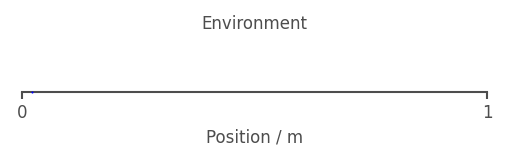

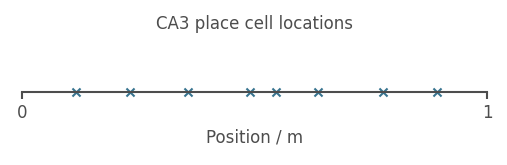

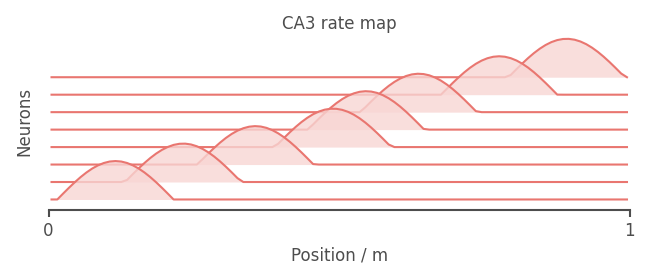

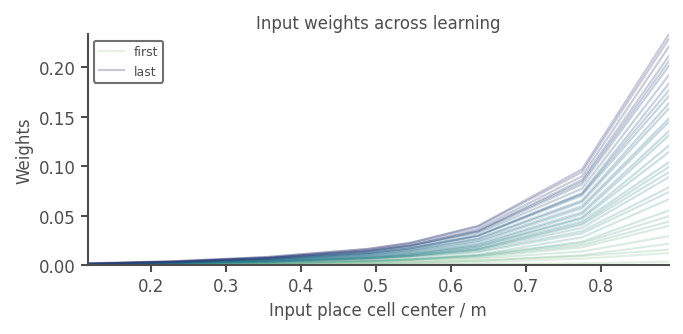

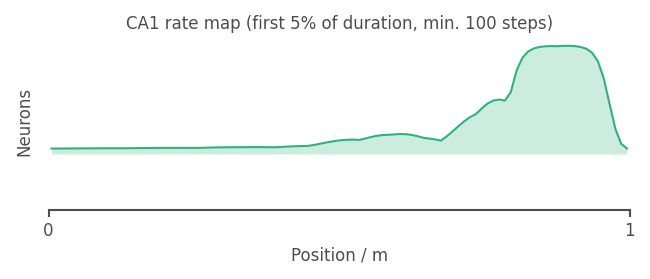

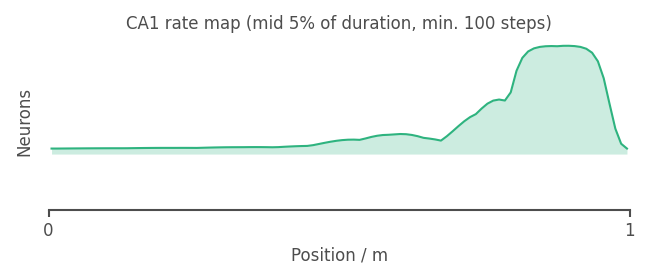

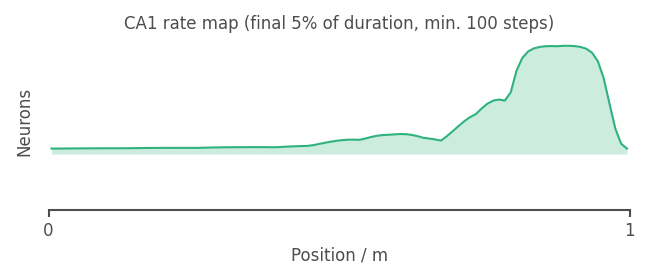

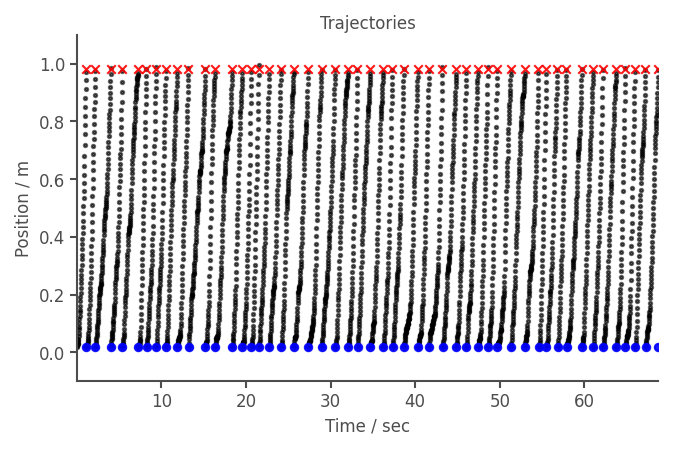

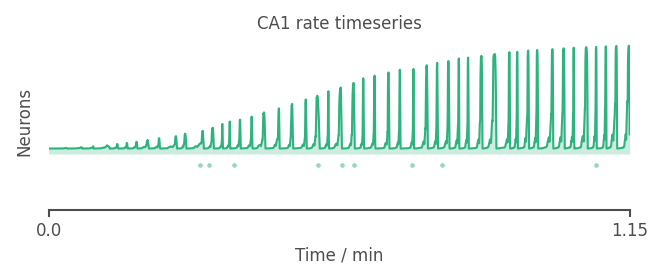

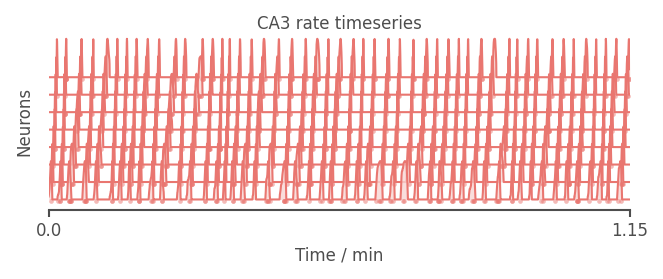

In [10]:
Env, Ag, CA1, CA3_PCs = learn(
    env_params, 
    agent_params, 
    CA3_PC_params, 
    CA1_params_one, 
    num_rwd=NUM_RWD, 
    max_steps=MAX_STEPS
)

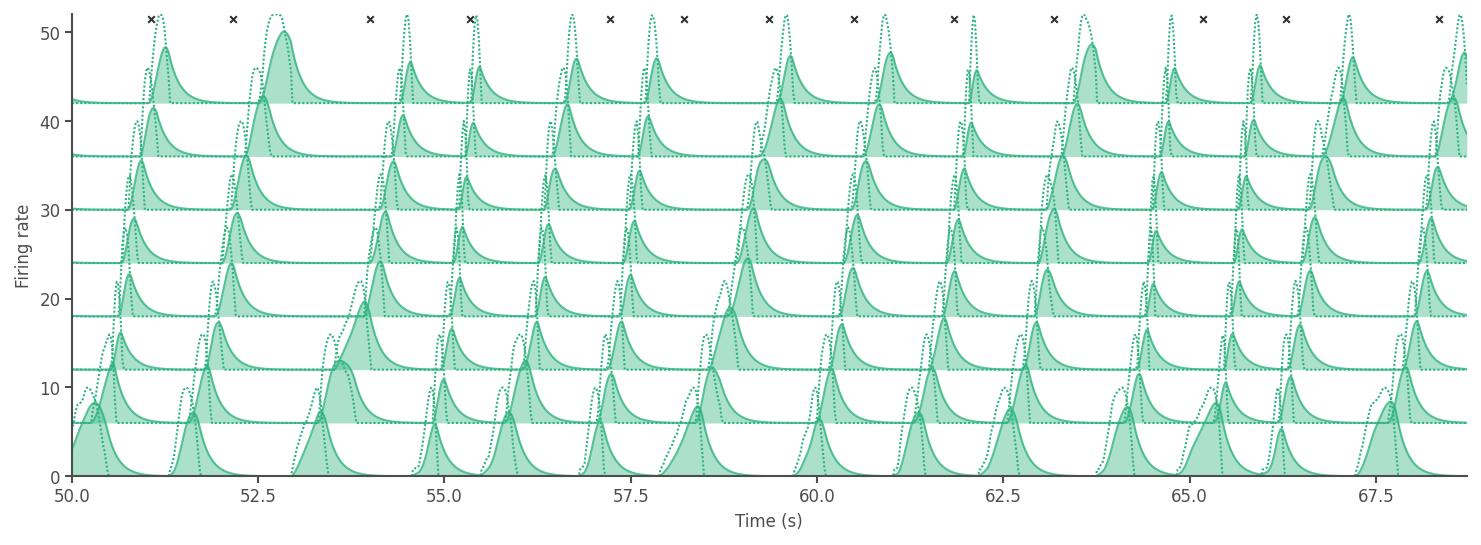

In [11]:
CA1.plot_btsp_filtered("CA3_PCs", t_start=50);

## Multiple CA1 neurons

In [12]:
import importlib
importlib.reload(neurons)

<module 'predhpc.neurons' from '/home/cgillon/Documents/predhpc/scripts/../predhpc/neurons.py'>

In [13]:
NUM_CA1 = 4

CA1_ZERO = False
CA1_SCALE = 0.1

NUM_RWD = 50
MAX_STEPS = 5000

CA1_params_mult = copy.deepcopy(CA1_params)
CA1_params_mult["n"] = NUM_CA1
CA1_params_mult["init_weights_zero"] = CA1_ZERO
CA1_params_mult["w_init_scale"] = CA1_SCALE

# CA3 PCs       : 8
# CA1s          : 4
CA1 init at 0   : False
CA1 init scale  : 0.1
# rewards       : 50
Max # steps     : 5000



 70%|█████████████████████████▊           | 3491/5000 [00:00<00:00, 3893.17it/s]


Trajectory lengths (51) to date: 1.37 +/- 0.36 sec each
Trajectory lengths (51) to date: 68.47 +/- 18.18 steps each


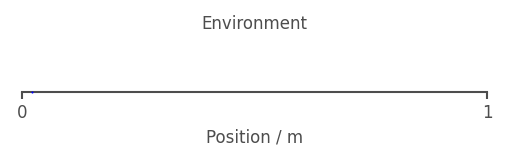

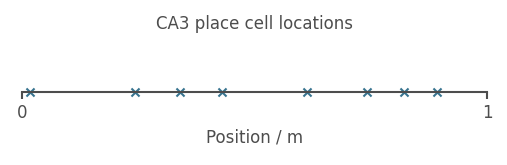

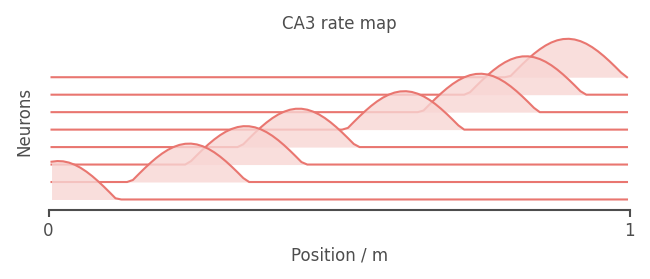

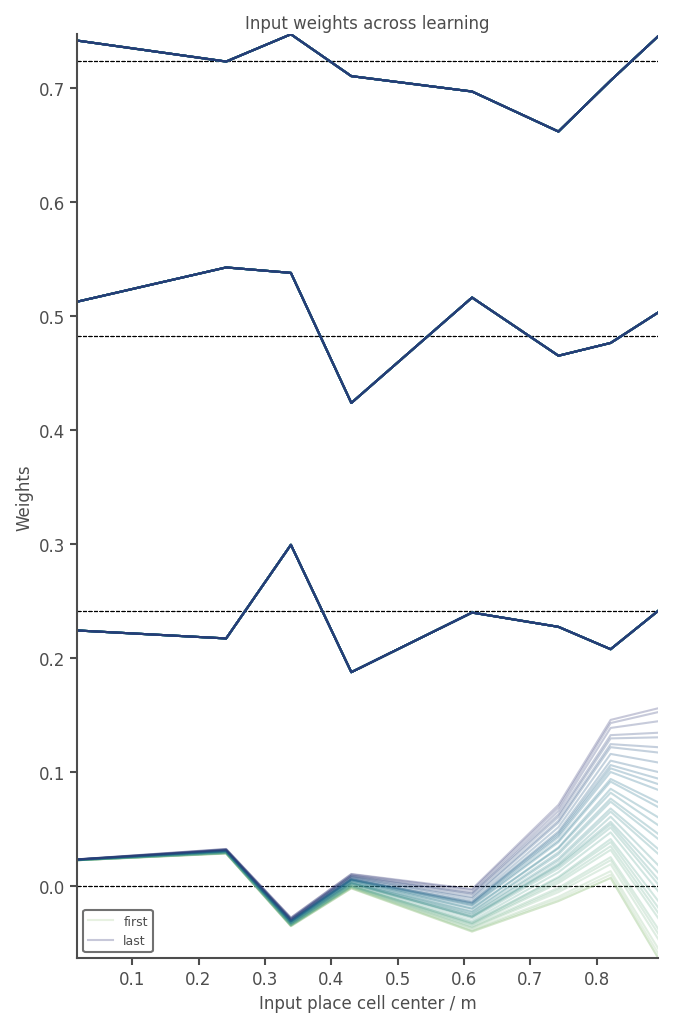

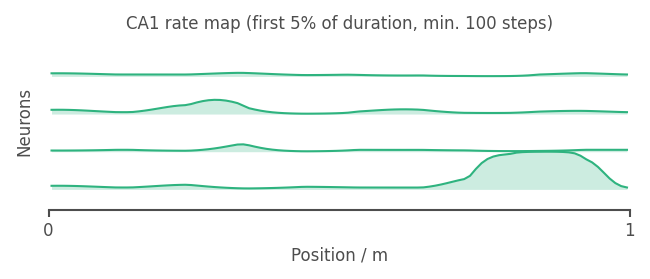

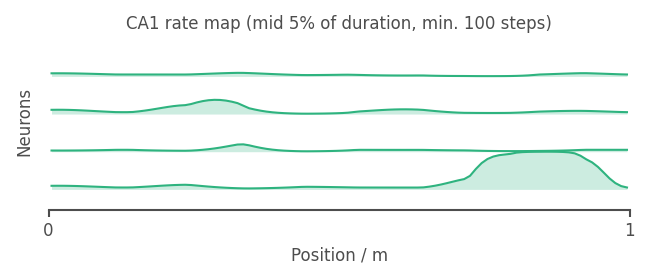

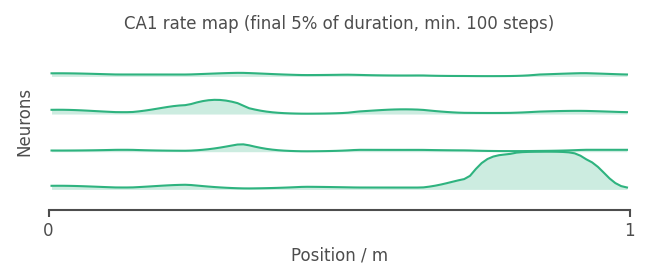

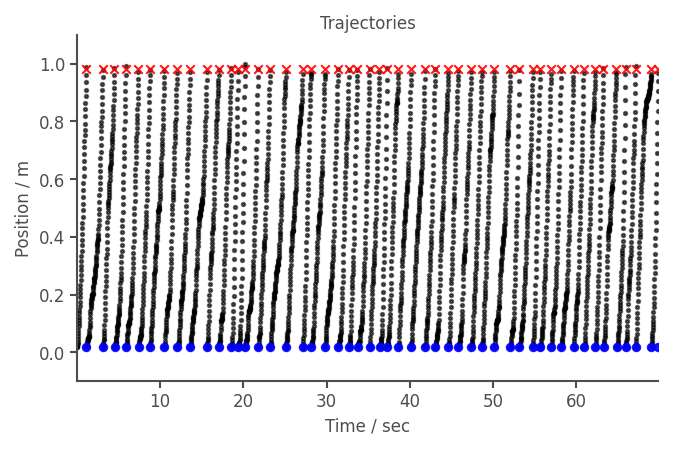

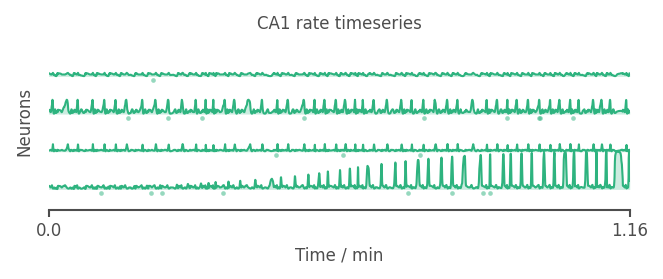

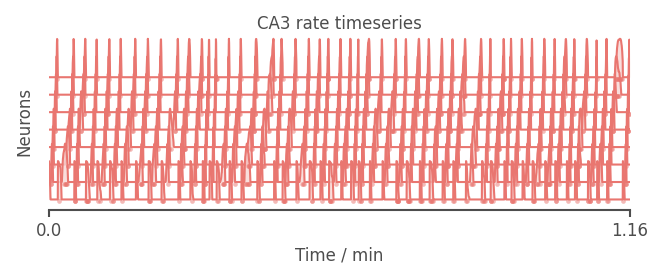

In [14]:
Env, Ag, CA1, CA3_PCs = learn(
    env_params, 
    agent_params, 
    CA3_PC_params, 
    CA1_params_mult, 
    num_rwd=NUM_RWD, 
    max_steps=MAX_STEPS
)

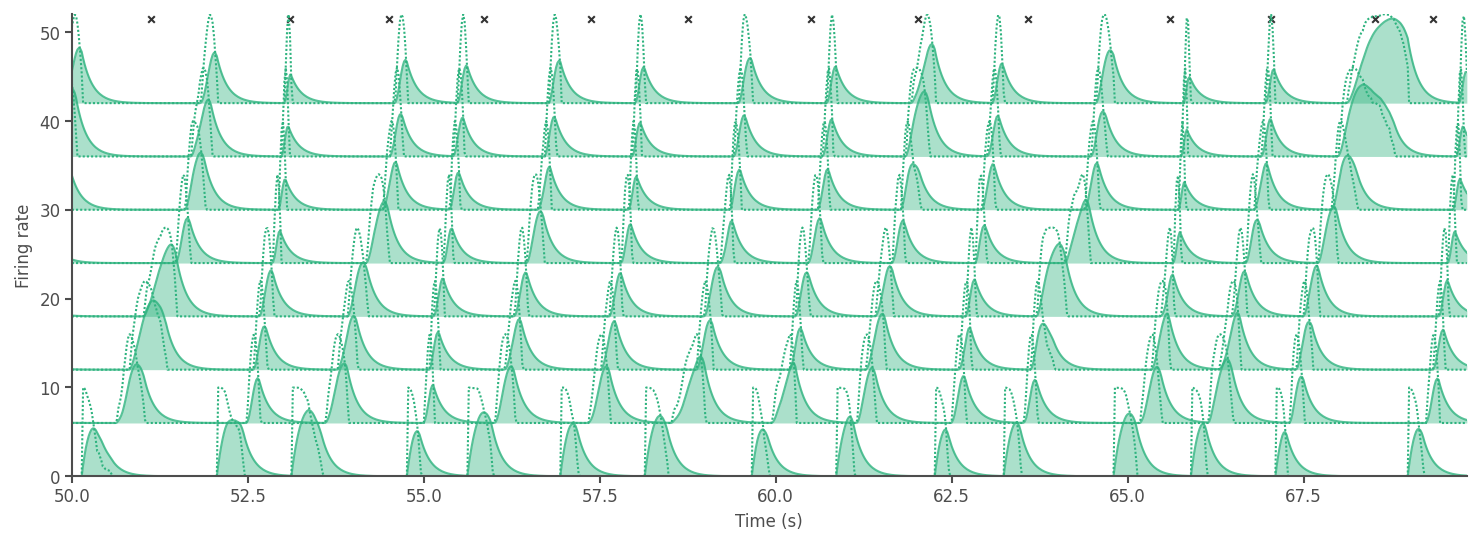

In [15]:
CA1.plot_btsp_filtered("CA3_PCs", t_start=50);

In [16]:
# Implement BTSP
# LR factor => convert to more three-factor like?

# Upgrade to a 2D environment

# Add more signals (e.g., Novelty)

# Expand the network to have an EC layer (i.e., encode more environment features)

# Expand the network to have a DG-like layer (i.e., memory)

# Closing the loop: predictiveness shaping reward/novelty signal